In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import tqdm
import seaborn as sns
import joblib
import itertools
import random
import copy

In [2]:
# Function to set random seed for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed) 
    np.random.seed(seed)
    random.seed(seed)

In [3]:
# Load all the numeric data
source = Path('../source/')
indpro = pd.read_excel(source / 'INDPRO.xlsx', sheet_name= 'Monthly')
unrate = pd.read_excel(source / 'UNRATE.xlsx', sheet_name= 'Monthly')
dff = pd.read_excel(source / 'FEDFUNDS.xlsx', sheet_name= 'Monthly')
cpi = pd.read_excel(source / 'CPIAUCSL.xlsx', sheet_name= 'Monthly')
epu = pd.read_excel(source / 'USEPUINDXD.xlsx', sheet_name= 'Monthly')
vix = pd.read_excel(source / 'VIXCLS.xlsx', sheet_name= 'Monthly')

# Join everything into a single df
data = indpro.merge(unrate, on = 'observation_date', how= 'outer')
data = data.merge(dff, on = 'observation_date', how = 'outer')
data = data.merge(cpi, on = 'observation_date', how = 'outer')
data = data.merge(epu, on = 'observation_date', how = 'outer')
data = data.merge(vix, on = 'observation_date', how = 'outer')

data.sort_values(by = 'observation_date', inplace= True)
data.columns = [col.lower() for col in data.columns] # Rename all columns to lowercase

del indpro, unrate, dff, cpi, epu, vix, source

# Stationarity

In [4]:
data['usepuindxd'] = (data['usepuindxd']/100) + 1 # EPU/100 + 1
apply_logs = ['cpiaucsl', 'indpro', 'vixcls', 'usepuindxd'] # Columns we'll apply logs to
log_cols = [f'log_{col}' for col in apply_logs] # Names of the log columns
data[log_cols] = np.log(data[apply_logs]) # Apply logs to the columns

# Compute log differences and plain differences
data["inflation"]    = 1200.0 * (data["log_cpiaucsl"] - data["log_cpiaucsl"].shift(1))
data["delta_indpro"] = 1200.0 * (data["log_indpro"]   - data["log_indpro"].shift(1))

del apply_logs, log_cols

# LSTM:

In [5]:
class MacroVariablesDataset(Dataset):
    def __init__(self, input_data: pd.DataFrame, scaler_x, scaler_y, forecast_horizon: int, max_len: int, cut : int | None = None, train: bool = True):
        self.data = input_data.copy()
        self.scaler_x = scaler_x
        self.scaler_y = scaler_y
        self.forecast_horizon = forecast_horizon
        columns = list(self.data.columns)
        self.max_len = max_len

        if cut is None:
            cut = int(len(self.data) * 0.8)
        # For the training dataset, we'll fit the scaler and then for the test dataset, we'll use the already fitted scaler
        if train:
            self.data = self.data.iloc[:cut, :].copy() # For the training dataset, we just select the observations up to the cut
        else:
            assert cut > self.max_len + self.forecast_horizon, f"Not enough observations for the buffer: cut = {cut}, max_len = {self.max_len}" # Just in case
            buffer_start = cut - self.max_len - self.forecast_horizon # We need at least max_len + forecast_horizon observations for the buffer
            self.data = self.data.iloc[buffer_start:, :].copy() # This will be our test dataset, which will include the buffer

        # Create our y variables with the desired horizon and keep track ofs our target variables
        self.data, self.targets = self.create_target(self.data, self.forecast_horizon, columns)
        # These will be our features
        self.features = [col for col in self.data.columns if col not in self.targets]

        # We'll only fit the scaler on the training data and use the already fitted scaler for testing
        if train:
            X = self.scaler_x.fit_transform(self.data[self.features].astype(np.float32))
            y = self.scaler_y.fit_transform(self.data[self.targets].astype(np.float32))
        else:
            X = self.scaler_x.transform(self.data[self.features].astype(np.float32)) # Use already fitted scaler
            y = self.data[self.targets].to_numpy(np.float32) # y unscaled

        self.n_obs = X.shape[0]
        sequences = []
        lengths = []
        for i in range(self.n_obs):
            xt = X[:i+1, :] # For time t, select all observations from j = 0, ..., t]
            xt, L = self.pad_sequence(xt, dtype= torch.float) # Pad the sequence and get the length
            lengths.append(L) # Record every length
            sequences.append(xt) # Create an array of sequences

        self.X = torch.stack(sequences) # Create the X
        self.y = torch.tensor(y, dtype = torch.float)
        self.lengths = torch.tensor(lengths, dtype = torch.long)

        # During testing, we want to cut out the buffer observations
        if not train:
            self.X = self.X[max_len:]
            self.y = self.y[max_len:]
            self.lengths = self.lengths[max_len:]

    # This function creates the target variables
    def create_target(self, data: pd.DataFrame, forecast_horizon: int, col_list: list):
        data = data.copy()
        shift_nmbr = -forecast_horizon
        targets = []
        for col in col_list:
            data[f'f{forecast_horizon}_{col}'] = data[col].shift(shift_nmbr)
            targets.append(f'f{forecast_horizon}_{col}')
        data = data.dropna().reset_index(drop=True) # For now I'll just drop all NAs
        return data, targets
    
    # This will pad the training sequences with zeros if they are shorter than max_len and also truncate them if they are longer
    def pad_sequence(self, sequence, dtype):
        nrows, ncols = sequence.shape
        if nrows < self.max_len: # If shorter
            seq = torch.cat([torch.tensor(sequence, dtype= dtype), torch.zeros(self.max_len - nrows, ncols, dtype = dtype)]) # concatenate with zeros
            seq = seq[-self.max_len:, :] 
            return seq, nrows
        else:
            seq = torch.tensor(sequence, dtype= dtype)
            trunc_seq = seq[-self.max_len:, :] # Truncate if longer
            return trunc_seq, self.max_len
    
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


In [6]:
# This class will set up our LSTM architecture
class LSTMForecasting(nn.Module):
    def __init__(self, input_cols: list, target_cols: list, hidden_size: int, num_layers: int, p_dropout: float, bidirectional : bool = False):
        super(LSTMForecasting, self).__init__()
        self.input_cols = list(input_cols)
        input_size = len(self.input_cols)
        self.targets = list(target_cols)
        self.n_outputs = len(self.targets)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first= True, dropout= p_dropout, bidirectional= bidirectional)

        self.fc = nn.Linear((2 * hidden_size), self.n_outputs) if bidirectional else nn.Linear((hidden_size), self.n_outputs)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(p_dropout),
            self.fc,
        )
        self.attention = nn.Linear(2 * hidden_size, 1) if bidirectional else nn.Linear(hidden_size, 1)
    
    def forward(self, xnum, lengths):
        _, T, _ = xnum.shape
        packed = pack_padded_sequence(xnum, lengths.cpu(), batch_first= True, enforce_sorted= False) # This is so that the GRU doesn't process all the padding
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=T) # Add the padding back
        device = out.device
        mask = (torch.arange(T, device=device).unsqueeze(0) < lengths.to(device).unsqueeze(1)) # This is 1 if there's a real value and 0 if there's padding
        scores = self.attention(out).squeeze(-1) # Pass through the attention block
        scores = scores.masked_fill(~mask, -1e9) # Set all the padding scores to essentially zero
        weights = torch.softmax(scores, dim=1) # Compute scores
        context = torch.sum(out * weights.unsqueeze(-1), dim=1) # Weighted average of the GRU output
        x = self.head(context) # Linear layer for regression
        return x, weights


In [7]:
class HighCapacityLSTMForecasting(nn.Module):
    def __init__(self, input_cols: list, target_cols: list, hidden_size: int, num_layers: int, p_dropout: float, bidirectional : bool = False):
        super(HighCapacityLSTMForecasting, self).__init__()
        self.input_cols = list(input_cols)
        input_size = len(self.input_cols)
        self.targets = list(target_cols)
        self.n_outputs = len(self.targets)
        self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers, batch_first= True, dropout= p_dropout, bidirectional= bidirectional)
        self.lstm2 = nn.LSTM(input_size, hidden_size, num_layers, batch_first= True, dropout= p_dropout, bidirectional= bidirectional)

        self.fc = nn.Linear(2 * (2 * hidden_size), 64) if bidirectional else nn.Linear(2 * (hidden_size), 64)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(p_dropout),
            self.fc,
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(64, self.n_outputs)
        )
        self.attention1 = nn.Linear(2 * hidden_size, 1) if bidirectional else nn.Linear(hidden_size, 1)
        self.attention2 = nn.Linear(2 * hidden_size, 1) if bidirectional else nn.Linear(hidden_size, 1)
    
    def forward(self, xnum, lengths):
        _, T, _ = xnum.shape
        device = xnum.device

        packed = pack_padded_sequence(
            xnum,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        out1, _ = self.lstm1(packed)
        out2, _ = self.lstm2(packed)

        out1, _ = pad_packed_sequence(out1, batch_first=True, total_length=T)
        out2, _ = pad_packed_sequence(out2, batch_first=True, total_length=T)

        mask = (
            torch.arange(T, device=device).unsqueeze(0)
            < lengths.to(device).unsqueeze(1)
        )

        scores1 = self.attention1(out1).squeeze(-1)
        scores2 = self.attention2(out2).squeeze(-1)

        scores1 = scores1.masked_fill(~mask, -1e9)
        scores2 = scores2.masked_fill(~mask, -1e9)

        weights1 = torch.softmax(scores1, dim=1)
        weights2 = torch.softmax(scores2, dim=1)

        context1 = torch.sum(out1 * weights1.unsqueeze(-1), dim=1)
        context2 = torch.sum(out2 * weights2.unsqueeze(-1), dim=1)

        context = torch.cat([context1, context2], dim=1)

        x = self.head(context)
        weights = 1/2 * weights1 + 1/2 * weights2
        return x, weights


In [8]:
def train_model(model, dataset, device, batch_size = 64, num_epochs = 100, lr = 3e-4, l2 = 0.0, qui = False, seed = 42, val_dataset = None, patience = 5):
    set_seed(seed)
    model.to(device)
    criterion = nn.MSELoss() 
    dataloader = DataLoader(dataset, batch_size= batch_size, shuffle = True) # Create a dataloader from the dataset to iterate over it in batches
    val_loader = DataLoader(val_dataset, batch_size= batch_size, shuffle= False) if val_dataset is not None else [] # Validation dataloader if we're using validation set
    optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay= l2) # Adam optimizer

    scaler_y = dataset.scaler_y
    avg_loss = None
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    best_epoch = num_epochs
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0 # To keep track of the average loss for each epoch
        for xnum, y, lengths in dataloader:
            xnum, y = xnum.to(device), y.to(device).float()
            optimizer.zero_grad() # Re initialize gradients on each iteration
            output, _ = model(xnum, lengths) # Forward pass
            loss = criterion(output, y) # Compute loss

            loss.backward() # Compute gradients
            optimizer.step() # Update weights
            running_loss += loss.item()

        avg_loss = running_loss/len(dataloader) # Compute average loss for each epoch
    
        if val_dataset is not None:
            model.eval() # Evaluation mode
            val_loss = 0.0
            with torch.no_grad(): # We don't need gradients for validation
                for xnum, y, lengths in val_loader:
                    xnum, y = xnum.to(device), y.to(device).float()
                    output, _ = model(xnum, lengths) # Forward pass
                    output = output.detach().cpu().numpy() # To use the inverse scaler, we need to get it out of the GPU
                    output = torch.tensor(scaler_y.inverse_transform(output), dtype = torch.float).to(device) # Inverse transform the predictions to get into original scale
                    val_loss += criterion(output, y).item() # Compute validation loss
            val_loss /= len(val_loader)
            # Store results for the best models based on validation loss and implement early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch
                epochs_no_improve = 0  
            else:
                epochs_no_improve += 1
            
            print(f"Epoch {epoch}: train={avg_loss:.4f}, val={val_loss:.4f}") if not qui else None
            # Early stopping if validation loss hasn't improved for a while
            if epochs_no_improve >= patience:
                print(f'Early Stopping at epoch: {epoch}') if not qui else None
                break
        else:
            print(f"Average loss for epoch {epoch}: {avg_loss}") if not qui else None

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, avg_loss, best_epoch

In [9]:
def evaluate_model(model, dataset, device, batch_size=64, verbose=True):
    model.to(device)
    model.eval()
    scaler_y = dataset.scaler_y
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    y_true = dataset.y.cpu().numpy()
    all_preds = []
    attn_list = []
    with torch.no_grad():
        for xnum, y, lengths in dataloader:
            xnum = xnum.to(device)
            y = y.to(device).float()
            lengths = lengths.to(device)
            output, attn_weights = model(xnum, lengths)
            output = output.detach().cpu().numpy() # Turn from torch tensor to numpy
            output = scaler_y.inverse_transform(output)

            all_preds.append(output)
            attn_list.append(attn_weights.cpu().numpy())

    y_pred = np.concatenate(all_preds, axis=0)
    attn = np.concatenate(attn_list, axis=0)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    if verbose:
        print(f'MSE:   {mse:.3f}')
        print(f'MAE:   {mae:.3f}')
        print(f'RMSE:  {rmse:.3f}')
    return mse, mae, rmse, y_true, y_pred, attn

In [10]:
# This class will set up the data for model training and also perform GridSearch for the LSTM model
class DLHyperparameterSearch():
    def __init__(self, data, forecast_horizon, cut, max_len, validation = True):
        self.fh = forecast_horizon
        self.max_len = max_len
        self.validation = validation

        self.data = data.copy()

        # Set up Scalers and Datasets
        self.scaler_x = StandardScaler()
        self.scaler_y = StandardScaler()

        # When we want to perform a grid search, we also need a validation set
        if validation:
            self.train_data = data.iloc[:cut].copy()
            self.validation_cut = int(cut * 0.85) # 85% for training and 15% for validation
            self.train_dataset = MacroVariablesDataset(self.train_data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = self.validation_cut, train = True)
            # Validation will be treated as a test set
            self.val_dataset = MacroVariablesDataset(self.train_data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = self.validation_cut, train = False)
        else:
            # Whenever we don't want to perform a grid search, it just sets up the training and test datasets
            # This will allow to retrain with the optimal hyperparameters on the full training set
            self.test_data = data.iloc[cut:].copy()
            self.train_dataset = MacroVariablesDataset(self.data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = cut, train = True)
            self.test_dataset = MacroVariablesDataset(self.data, self.scaler_x, self.scaler_y, self.fh, self.max_len, cut = cut, train = False)

    def fit(self, param_grid, device, num_epochs = 100, batch_size = 64, seed = 42, patience = 5):
        assert self.validation, "fit only supported when validation is True"
        self.param_grid = param_grid
        self.device = device
        self.seed = seed
        self.features = self.train_dataset.features
        self.targets = self.train_dataset.targets

        best_val_mse = float('inf')
        self.best_params = None
        tuning_results = []
        keys = list(param_grid.keys())
        for combo in itertools.product(*param_grid.values()):
            hp = dict(zip(keys, combo))
            if hp['num_layers'] == 1 and hp['p_dropout'] != 0: # this hyperparameter combination doesn't make sense, so we don't even bother
                continue
                
            set_seed(self.seed)
            # Instantiate model
            model = HighCapacityLSTMForecasting(input_cols= self.features, target_cols= self.targets, hidden_size= hp['hidden_size'], 
                                    num_layers= hp['num_layers'], p_dropout=hp['p_dropout'], bidirectional = hp['bidirectional'])
            
            # Train the model and get the epoch with the best oos performance on the validation set
            model, _, epoch_stop = train_model(model, self.train_dataset, device, batch_size= batch_size, num_epochs= num_epochs, lr = hp['lr'],
                                                l2 = hp['l2'], qui= True, val_dataset= self.val_dataset, patience = patience, seed = self.seed)
            
            # Evaluate on the validation set and store results
            val_mse, val_mae, val_rmse, _, _, _ = evaluate_model(model, self.val_dataset, self.device, verbose = False)
            tuning_results.append({**hp, 'val_mse': val_mse, 'val_mae': val_mae, 'val_rmse': val_rmse})
            if val_mse < best_val_mse:
                best_val_mse = val_mse
                self.best_score = val_mse
                self.best_params = hp
                self.best_params['early_stop'] = epoch_stop
                self.best_model = copy.deepcopy(model)
            
        return self.best_params, tuning_results


# Evaluation:

In [11]:
# Set up data
stationary_columns = ['inflation', 'delta_indpro', 'unrate', 'log_vixcls', 'log_usepuindxd', 'fedfunds']
stationary_data = data[stationary_columns].dropna().reset_index(drop = True).copy()

In [12]:
# Knowing how many observation we have for training and testing
initial_cut = int(len(stationary_data) * 0.8)
initial_test_len = len(stationary_data) - initial_cut
print(f"Initial train set size: {initial_cut}")
print(f"\nInitial test set size: {initial_test_len}")

Initial train set size: 345

Initial test set size: 87


## Hyperparameter tuning:

In [13]:
# This function will set up the data for each forecast horizon and perform a grid search, then will store the best model for each fh
def select_dl_model(data: pd.DataFrame, param_grid: dict, cut: int, forecast_horizon_grid: list, max_len: int, device, output_dir = '../output/robustness'):
    os.makedirs(output_dir, exist_ok= True)
    # Iterate over forecast horizons
    for fh in tqdm.tqdm(forecast_horizon_grid):
        print(f"Tuning for best model with forecast horizon {fh}...")

        # set up search, validation is set to True by default
        dl_search = DLHyperparameterSearch(data, forecast_horizon= fh, cut= cut, max_len= max_len)
        best_params, _ = dl_search.fit(param_grid, device)
        best_score = dl_search.best_score

        print(f"Best DL hyperparameters for fh {fh}: {best_params}; best validation MSE: {best_score:.4f}")
        joblib.dump({'best_params': best_params}, f"{output_dir}/best_dl_hp_{fh}.pkl")

In [ ]:
param_grid = {
    'hidden_size': [80, 96, 112, 124],
    'num_layers': [1, 2, 3, 4],
    'lr': [1e-3, 1e-4],
    'p_dropout': [0.0, 0.05, 0.1],
    'l2': [0.0, 1e-3, 5e-3, 1e-2],
    'bidirectional': [False, True]
}
fh_grid = [1, 3, 6]
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
select_dl_model(stationary_data, param_grid, initial_cut, fh_grid, max_len = 24, device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Tuning for best model with forecast horizon 1...


 33%|███▎      | 1/3 [3:00:23<6:00:46, 10823.09s/it]

Best DL hyperparameters for fh 1: {'hidden_size': 112, 'num_layers': 4, 'lr': 0.001, 'p_dropout': 0.1, 'l2': 0.001, 'bidirectional': True, 'early_stop': 10}; best validation MSE: 8.0082
Tuning for best model with forecast horizon 3...


 67%|██████▋   | 2/3 [5:56:50<2:58:04, 10684.50s/it]

Best DL hyperparameters for fh 3: {'hidden_size': 112, 'num_layers': 4, 'lr': 0.001, 'p_dropout': 0.05, 'l2': 0.001, 'bidirectional': True, 'early_stop': 9}; best validation MSE: 8.3413
Tuning for best model with forecast horizon 6...


## Model Comparison

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

fh_grid = [1, 3, 6]
evaluation_results = []
attention_results = []
for fh in fh_grid:
    # Set up the data for the LSTM
    dl_base_setup = DLHyperparameterSearch(stationary_data, forecast_horizon= fh, cut = initial_cut, max_len= 24, validation= False)
    dl_base_hyp = joblib.load(f"../output/best_dl_hp_{fh}.pkl")['best_params']
    train_base = dl_base_setup.train_dataset
    test_base = dl_base_setup.test_dataset
    dl_setup = DLHyperparameterSearch(stationary_data, forecast_horizon= fh, cut = initial_cut, max_len= 24, validation = False)
    dl_hyp = joblib.load(f"../output/robustness/best_dl_hp_{fh}.pkl")['best_params'] # Load the best hyperparameters
    train_dl = dl_setup.train_dataset
    test_dl = dl_setup.test_dataset

    set_seed(42)
    # instantiate model
    dl_model = HighCapacityLSTMForecasting(input_cols= train_dl.features, target_cols= train_dl.targets, hidden_size= dl_hyp['hidden_size'], 
                            num_layers= dl_hyp['num_layers'], p_dropout= dl_hyp['p_dropout'], bidirectional= dl_hyp['bidirectional'])
    
    set_seed(42)
    base_model = LSTMForecasting(input_cols= train_base.features, target_cols= test_base.targets, hidden_size= dl_base_hyp['hidden_size'], 
                            num_layers= dl_base_hyp['num_layers'], p_dropout= dl_base_hyp['p_dropout'], bidirectional= dl_base_hyp['bidirectional'])
    
    # Train
    dl_model, _, _ = train_model(dl_model, train_dl, device, batch_size= 64, num_epochs= dl_hyp['early_stop'], 
                                        lr= dl_hyp['lr'], l2 = dl_hyp['l2'], qui = True, seed= 42)
    
    base_model, _, _ = train_model(base_model, train_base, device, batch_size= 64, num_epochs= dl_base_hyp['early_stop'],
                                   lr = dl_base_hyp['lr'], l2 = dl_base_hyp['l2'], qui = True, seed = 42)
    # Evaluate
    dl_mse, dl_mae, dl_rmse, dl_true, dl_pred, attn = evaluate_model(dl_model, test_dl, device, batch_size= 64, verbose= False)
    attention_results.append(attn)

    evaluation_results.append({
        'model': 'DL High Capacity',
        'forecast_horizon': fh,
        'mse': dl_mse,
        'mae': dl_mae,
        'rmse': dl_rmse,
        'y_true': dl_true,
        'y_pred': dl_pred,
    })
    
    dl_mse, dl_mae, dl_rmse, dl_true, dl_pred, attn = evaluate_model(base_model, test_base, device, batch_size= 64, verbose= False)

    evaluation_results.append({
        'model': 'DL Base',
        'forecast_horizon': fh,
        'mse': dl_mse,
        'mae': dl_mae,
        'rmse': dl_rmse,
        'y_true': dl_true,
        'y_pred': dl_pred,
    })

evaluation_results = pd.DataFrame(evaluation_results)


Total Parameters in the deep learning model for forecast horizon 1: 28727
Total Parameters in the deep learning model for forecast horizon 3: 257047
Total Parameters in the deep learning model for forecast horizon 6: 257047


In [ ]:
# We also want to have the errors deaggregated by variable, so we construct a long dataset deaggregated by variable, with each individual forecasting error
individual_errors = []
for _, row in evaluation_results.iterrows():
    model = row['model']
    fh = row['forecast_horizon']
    y_pred = np.asarray(row['y_pred'])
    y_true = np.asarray(row['y_true'])
    for j in range(len(y_pred)):
        for k, var in enumerate(stationary_columns):
            error = y_pred[j][k] - y_true[j][k]
            individual_errors.append({
                'model': model,
                'forecast_horizon': fh,
                'variable': var,
                'y_true': y_true[j][k],
                'y_pred': y_pred[j][k],
                'error': error,
                'abs_error': abs(error),
                'sq_error': error ** 2
            })
individual_errors = pd.DataFrame(individual_errors)

In [ ]:
# Now we aggregate by variable
variable_metric_summary = (
    individual_errors
    .groupby(['model', 'forecast_horizon', 'variable'])
    .agg(
        n_obs=('error', 'size'),
        mae=('abs_error', 'mean'),
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        bias=('error', 'mean'),
    )
    .reset_index()
)

In [ ]:
# Overall average model performance
global_perf = variable_metric_summary.groupby(['forecast_horizon', 'model']).agg(avg_mae=('mae', 'mean'), avg_rmse=('rmse', 'mean'))
# Table with individual variables as columns and the forecast horzon-model combination as rows. Each value is one of the evaluation metrics
wide_perf = (variable_metric_summary.pivot_table(
    index=['forecast_horizon', 'model'],
    columns='variable',
    values=['mae', 'rmse']
    )
)
wide_perf = wide_perf.swaplevel(0, 1, axis=1)
wide_perf = wide_perf.sort_index(axis=1, level=0)
wide_perf[('Average', 'MAE')] = global_perf['avg_mae']
wide_perf[('Average', 'RMSE')] = global_perf['avg_rmse']
wide_perf.columns = pd.MultiIndex.from_tuples([(var.replace('_', " ").title(), metric.upper()) for var, metric in wide_perf.columns])
wide_perf = wide_perf.sort_index(level=['forecast_horizon', 'model'])
wide_perf.index.set_names(['Forecast Horizon', 'Model'], inplace=True)
# Table reporting results
latex_table = wide_perf.to_latex(
    "../output/robustness/numeric_models_performance.tex",
    multicolumn=True,
    multirow=True,
    float_format="%.3f",
    caption="Forecast performance by horizon, model, and variable",
    label="tab:numeric_models_evaluation",
    escape=False
)

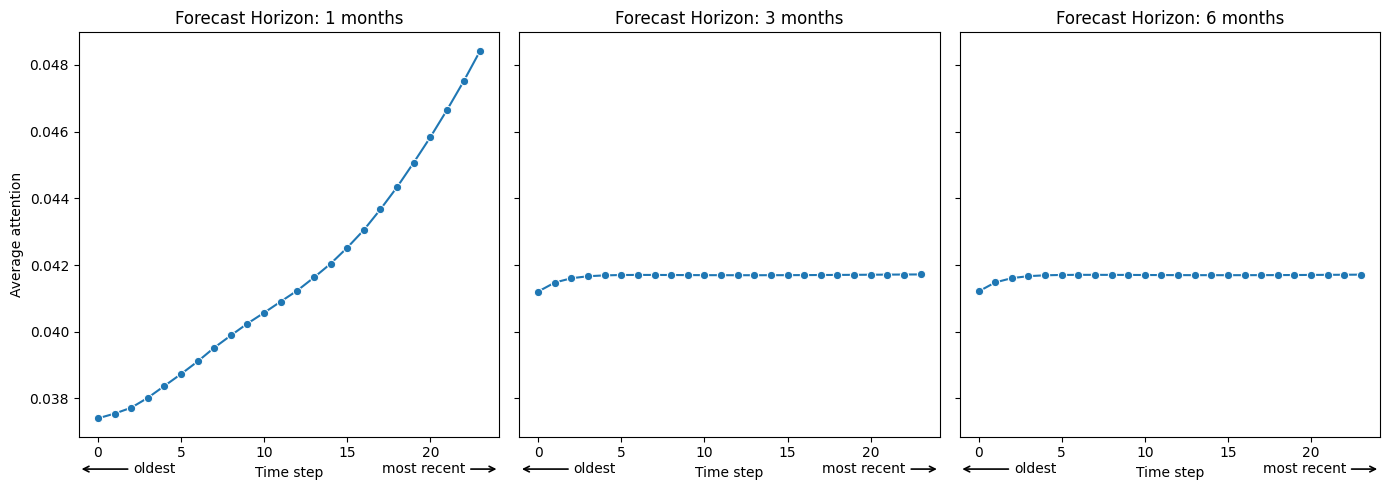

In [ ]:
# Attention over the test set
fig, axes = plt.subplots(1, len(fh_grid), figsize=(14, 5), sharey = True)
for i, (ax, fh) in enumerate(zip(axes, fh_grid)):
    mean_attn = attention_results[i].mean(axis = 0)
    sns.lineplot(x=np.arange(len(mean_attn)), y=mean_attn, marker='o', ax = ax)

    ax.set_title(f'Forecast Horizon: {fh} months')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Average attention')
    ax.annotate(
        'oldest',
        xy=(0.00, -0.08),
        xytext=(0.18, -0.08),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        arrowprops=dict(arrowstyle='->', lw=1.2)
    )
    ax.annotate(
        'most recent',
        xy=(1.00, -0.08),
        xytext=(0.82, -0.08),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        arrowprops=dict(arrowstyle='->', lw=1.2)
    )
plt.tight_layout()
plt.savefig('../output/robustness/attention_results.png', dpi = 300)
plt.show()